<img src="img/Recurso.jpeg" alt="logo itq" width="150">

# Análisis Exploratorio de Datos

<img src="img/Logo.jpeg" alt="logo itq" width="150">

## Spotify-2023
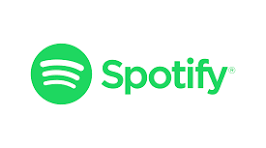
**Nombre del programador:** Evelyn Lascano<br>
**Fecha:** 16/02/2026

### Análisis del Dataset de Tracks de Spotify 2023 (114,000+ canciones)

* **Origen:** Dataset de Kaggle (Maharshi Pandya) con datos de la API de Spotify.
* **Objetivo:** Desarrollar un análisis integral y procesamiento de datos del ecosistema musical de Spotify durante el año 2023, mediante la implementación de técnicas de limpieza, normalización y visualización estadística, con el fin de identificar los patrones de éxito, las métricas de audio predominantes y los perfiles de los artistas con mayor impacto en la plataforma.

## Bloque 1
* **Configuración Global y Carga**<br>
En esta celda se prepara todas las librerías y se toma los datos iniciales.

In [59]:
import pandas as pd # Para manejar tablas.
import numpy as np #Para operaciones matemáticas.
import matplotlib.pyplot as plt #Para las gráficas
import seaborn as sns # Añadimos esta para gráficos más profesionales

In [60]:
#Se carga el dataset "Tracks de Spotify 2023"
# index_col=0 evita la columna extra de números 'Unnamed: 0'
df = pd.read_csv('dataset.csv', index_col=0)

#Vista previa de los datos
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Soundtrack),Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [61]:
#DIAGNÓSTICO INICIAL DEL DATASET 

#Se capturan las dimensiones originales del dataset para permitir el cálculo 
filas_inicio = df.shape[0]
columnas_inicio = df.shape[1]

#Información inicial del dataset Spotify 2023.
print("CONFIGURACIÓN INICIAL")
print(f"Librerías cargadas: pandas, numpy, matplotlib y seaborn.")
print(f"El dataset inicia con: {filas_inicio:,} registros y {columnas_inicio} columnas.")


CONFIGURACIÓN INICIAL
Librerías cargadas: pandas, numpy, matplotlib y seaborn.
El dataset inicia con: 114,000 registros y 20 columnas.


In [62]:
#Ver los nombres de las columnas para saber qué limpiar
print("COLUMNAS DISPONIBLES")
#Se Limpia los nombres de columnas (quita espacios invisibles)
#La función  .str.strip(), es  la herramienta estándar y más eficiente en Pandas para limpiar los nombres de las columnas,quita espacios.
df.columns = df.columns.str.strip()
print(df.columns.tolist())

COLUMNAS DISPONIBLES
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [63]:
#TRADUCCIÓN DE COLUMNAS A ESPAÑOL 
#Se rea un diccionario para renombrar las columnas principales
diccionario_espanol = {
    'track_id': 'Id Cancion',
    'artists': 'Artistas',
    'album_name': 'Nombre Album',
    'track_name': 'Nombre Cancion',
    'popularity': 'Popularidad',
    'duration_ms': 'Duracion ms',
    'explicit': 'Explicita',
    'danceability': 'Bailabilidad',
    'energy': 'Energia',
    'key': 'Tonalidad',
    'loudness': 'Volumen dB',
    'mode': 'Modo Musical',
    'speechiness': 'Presencia Voz',
    'acousticness': 'Acustica',
    'instrumentalness': 'Instrumentalidad',
    'liveness': 'En Vivo',
    'valence': 'Positividad',
    'tempo': 'Ritmo BPM',
    'time_signature': 'Compas',
    'track_genre': 'Genero'}

df.rename(columns=diccionario_espanol, inplace=True)

#Guarda los números iniciales para el reporte final
# Se actualiza el registro de dimensiones tras la carga y traducción, asegurando que la cantidad de registros se mantenga íntegra antes de iniciar la depuración.
filas_inicio = df.shape[0]

print(f" Dataset cargado y traducido. Columnas actuales:\n{df.columns.tolist()}")

 Dataset cargado y traducido. Columnas actuales:
['Id Cancion', 'Artistas', 'Nombre Album', 'Nombre Cancion', 'Popularidad', 'Duracion ms', 'Explicita', 'Bailabilidad', 'Energia', 'Tonalidad', 'Volumen dB', 'Modo Musical', 'Presencia Voz', 'Acustica', 'Instrumentalidad', 'En Vivo', 'Positividad', 'Ritmo BPM', 'Compas', 'Genero']



**Tabla Maestra: Diccionario de Variables - Spotify 2023**


In [64]:
#AJUSTE DE CONFIGURACIÓN DE PANDAS 

#Se configura el sistema para que muestre todas las columnas del DataFrame sin aplicar truncamiento visual (puntos suspensivos).
pd.set_option('display.max_columns', None)

#Opcional: Se ajusta el ancho de las columnas para que el contenido de texto (como el nombre de las canciones o álbumes) no se corte.
pd.set_option('display.max_colwidth', None)

#Ejecución de la vista previa de los primeros 20 registros
tabla = pd.read_csv('tabla.csv')
tabla.head(20)

,Categoría,Variable,Descripción Técnica
0,Identificación,Id Cancion,Identificador único global de Spotify para cada pista musical.
1,Identificación,Nombre Cancion,Título oficial de la obra musical.
2,Identificación,Artistas,Nombre del artista o lista de artistas que colaboran (separados por ;).
3,Identificación,Nombre Album,Título del álbum en el que se incluye la canción.
4,Identificación,Genero,Clasificación del género musical principal asignado a la pista.
5,Contexto,Explicita,Indicador (Booleano) que señala si la letra contiene lenguaje para adultos.
6,Rendimiento,Popularidad,Índice numérico (0-100) basado en reproducciones totales y actualidad.
7,Estructura,Duracion ms,Longitud de la pista medida en milisegundos.
8,Estructura,Ritmo BPM,Tempo estimado de la canción en pulsaciones por minuto (Beats Per Minute).
9,Estructura,Compas,Estimación del número de pulsos en cada compás (firma de tiempo).


## Bloque 2
* **Eliminación de Duplicados**<br>
Ahora que la columna se llama id_cancion, la usamos para limpiar las repeticiones.

In [65]:
# Usa el nuevo nombre 'Id Cancion' para eliminar duplicados
df.drop_duplicates(subset=['Id Cancion'], keep='first', inplace=True)

print(f" Duplicados eliminados.Registros actuales: {len(df):,}")

 Duplicados eliminados.Registros actuales: 89,741


## Bloque 3
* **Limpieza de Valores Nulos**<br>
Aseguramos que no haya "celdas vacías" en ninguna columna.

In [69]:
# Se elimina cualquier fila que tenga valores nulos (NaN)
# Mostra el conteo para el informe
print("Conteo de nulos antes de usar dropna:")
print(df.isnull().sum())
print("Conteo de nulos despues de usar dropna:")

#El comando df.dropn se utiliza para eliminar de forma permanente todas las filas que contengan al menos un valor nulo (NaN o Not a Number) en cualquiera de sus columnas.
df.dropna(inplace=True)
print(df.isnull().sum())
print("Datos nulos: El dataset ya no tiene celdas vacías.")

Conteo de nulos antes de usar dropna:
Id Cancion          0
Artistas            0
Nombre Album        0
Nombre Cancion      0
Popularidad         0
Duracion ms         0
Explicita           0
Bailabilidad        0
Energia             0
Tonalidad           0
Volumen dB          0
Modo Musical        0
Presencia Voz       0
Acustica            0
Instrumentalidad    0
En Vivo             0
Positividad         0
Ritmo BPM           0
Compas              0
Genero              0
dtype: int64
Conteo de nulos despues de usar dropna:
Id Cancion          0
Artistas            0
Nombre Album        0
Nombre Cancion      0
Popularidad         0
Duracion ms         0
Explicita           0
Bailabilidad        0
Energia             0
Tonalidad           0
Volumen dB          0
Modo Musical        0
Presencia Voz       0
Acustica            0
Instrumentalidad    0
En Vivo             0
Positividad         0
Ritmo BPM           0
Compas              0
Genero              0
dtype: int64
Datos nulos: El 

## Bloque 4
* **Normalización de Texto (Géneros,Artistas,Nombre Cancion,Nombre Album)**
Se pone orden en los textos para que la computadora no se confunda con mayúsculas o espacios.<br>
* **Cambio de la columna Explicita**

In [68]:
#Normalización a minúsculas y quitar espacios en blanco laterales
columnas_texto = ['Genero', 'Artistas', 'Nombre Cancion', 'Nombre Album']
for col in columnas_texto:
    df[col] = df[col].str.lower().str.strip()

#Limpieza de símbolos en 'Nombre Cancion'
#Elimina todo lo que esté después de un guion (-) o un paréntesis (
df['Nombre Cancion'] = df['Nombre Cancion'].str.split('-').str[0].str.strip()
df['Nombre Cancion'] = df['Nombre Cancion'].str.split('(').str[0].str.strip()

#CORRECCIÓN DE LA COLUMNA EXPLICITA

#Asegura que no haya nulos
df = df[df['Explicita'].notnull()]

#Opcional: Se puede cambiar True/False por Si/No para que las gráficas se vean mejor
df['Explicita'] = df['Explicita'].replace({True: 'Si', False: 'No'})

print(" Columna 'Explicita' procesada y traducida a Si/No.")

print("Texto normalizado: Minúsculas aplicadas y nombres de canciones simplificados.")
df.head()

 Columna 'Explicita' procesada y traducida a Si/No.
Texto normalizado: Minúsculas aplicadas y nombres de canciones simplificados.


,Id Cancion,Artistas,Nombre Album,Nombre Cancion,Popularidad,Duracion ms,Explicita,Bailabilidad,Energia,Tonalidad,Volumen dB,Modo Musical,Presencia Voz,Acustica,Instrumentalidad,En Vivo,Positividad,Ritmo BPM,Compas,Genero
0,5SuOikwiRyPMVoIQDJUgSV,gen hoshino,comedy,comedy,73,230666,No,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,ben woodward,ghost (acoustic),ghost,55,149610,No,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,ingrid michaelson;zayn,to begin again,to begin again,57,210826,No,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,kina grannis,crazy rich asians (original motion picture soundtrack),can't help falling in love,71,201933,No,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,chord overstreet,hold on,hold on,82,198853,No,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Bloque 5
* **Validación de Rangos Lógicos y conversión de tiempo**
Aquí se revisa que los números de las 20 columnas tengan sentido (ej. que la energía no sea negativa y la popularidad no pase de 100).

In [70]:
#Métricas que van de 0 a 1 (Aquí NO entra el Volumen)
metricas_es = ['Bailabilidad', 'Energia', 'Presencia Voz', 'Acustica', 
               'Instrumentalidad', 'En Vivo', 'Positividad']

for col in metricas_es:
    df = df[(df[col] >= 0) & (df[col] <= 1)]

#VALIDACIÓN DE VOLUMEN 
# El volumen es negativo, así que filtramos de -60 a 0. 
# Esto no afectará a las métricas anteriores.
df = df[(df['Volumen dB'] >= -60) & (df['Volumen dB'] <= 0)]

#Popularidad (0 a 100)
df = df[(df['Popularidad'] >= 0) & (df['Popularidad'] <= 100)]

#Creación de columna y filtro de tiempo (1 a 10 min)
#1 minuto= 60,000 milisegundos
df['Duracion Min'] = (df['Duracion ms'] / 60000).round(2) #Se aplica un redondeo a dos decimales.
df = df[(df['Duracion Min'] >= 1.0) & (df['Duracion Min'] <= 10.0)]

print("Validación completa: Métricas, Volumen (-60 a 0) y Duración ajustados.")

Validación completa: Métricas, Volumen (-60 a 0) y Duración ajustados.


In [18]:
df.head()

,Id Cancion,Artistas,Nombre Album,Nombre Cancion,Popularidad,Duracion ms,Explicita,Bailabilidad,Energia,Tonalidad,...,Modo Musical,Presencia Voz,Acustica,Instrumentalidad,En Vivo,Positividad,Ritmo BPM,Compas,Genero,Duracion Min
0,5SuOikwiRyPMVoIQDJUgSV,gen hoshino,comedy,comedy,73,230666,No,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.84
1,4qPNDBW1i3p13qLCt0Ki3A,ben woodward,ghost (acoustic),ghost,55,149610,No,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.49
2,1iJBSr7s7jYXzM8EGcbK5b,ingrid michaelson;zayn,to begin again,to begin again,57,210826,No,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.51
3,6lfxq3CG4xtTiEg7opyCyx,kina grannis,crazy rich asians (original motion picture sou...,can't help falling in love,71,201933,No,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.37
4,5vjLSffimiIP26QG5WcN2K,chord overstreet,hold on,hold on,82,198853,No,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.31


## Bloque 6
**Reporte Final de la Limpieza de datos**

In [71]:

print(" INICIANDO AUDITORÍA FINAL DE DATOS LIMPIOS\n")

#Verificación de Nulos (Debe ser 0)
nulos_finales = df.isnull().sum().sum()
print(f"1. Valores nulos en el dataset: {nulos_finales}")

#Verificación de Duplicados (Debe ser 0)
duplicados_finales = df.duplicated(subset=['Id Cancion']).sum()
print(f"2. Registros duplicados restantes: {duplicados_finales}")

#Verificación de Rango de Métricas (0 a 1)
#Prueba con 'Energia' como referencia
errores_rango = df[(df['Energia'] < 0) | (df['Energia'] > 1)].shape[0]
print(f"3. Registros fuera de rango (0-1) en métricas: {errores_rango}")

# 4. Verificación de Volumen (Debe estar entre -60 y 0)
errores_volumen = df[(df['Volumen dB'] < -60) | (df['Volumen dB'] > 0)].shape[0]
print(f"4. Registros con volumen fuera de rango (-60 a 0 dB): {errores_volumen}")

#Verificación de Duración (Debe estar entre 1 y 10 min)
min_t = df['Duracion Min'].min()
max_t = df['Duracion Min'].max()
print(f"5. Rango de duración validado: {min_t} min - {max_t} min")

#Verificación de Texto (Explicita)
print(f"6. Valores detectados en 'Explicita': {df['Explicita'].unique()}")

#RESULTADO FINAL
filas_final = len(df)
print("-" * 50)
print(f"AUDITORÍA COMPLETADA")
print(f"Registros originales: {filas_inicio:,}")
print(f"Registros limpios: {filas_final:,}")
print(f"Eficacia de limpieza: Se conservó el {(filas_final/filas_inicio)*100:.2f}% de los datos.")
print("-" * 50)

# Resumen técnico final
df.info()

# Muestra de los datos finales para asegurar que todo sea minúsculas y sin símbolos
df.head()

 INICIANDO AUDITORÍA FINAL DE DATOS LIMPIOS

1. Valores nulos en el dataset: 0
2. Registros duplicados restantes: 0
3. Registros fuera de rango (0-1) en métricas: 0
4. Registros con volumen fuera de rango (-60 a 0 dB): 0
5. Rango de duración validado: 1.0 min - 10.0 min
6. Valores detectados en 'Explicita': ['No' 'Si']
--------------------------------------------------
AUDITORÍA COMPLETADA
Registros originales: 114,000
Registros limpios: 88,369
Eficacia de limpieza: Se conservó el 77.52% de los datos.
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 88369 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id Cancion        88369 non-null  object 
 1   Artistas          88369 non-null  object 
 2   Nombre Album      88369 non-null  object 
 3   Nombre Cancion    88369 non-null  object 
 4   Popularidad       88369 non-null  int64  
 5   Dur

,Id Cancion,Artistas,Nombre Album,Nombre Cancion,Popularidad,Duracion ms,Explicita,Bailabilidad,Energia,Tonalidad,Volumen dB,Modo Musical,Presencia Voz,Acustica,Instrumentalidad,En Vivo,Positividad,Ritmo BPM,Compas,Genero,Duracion Min
0,5SuOikwiRyPMVoIQDJUgSV,gen hoshino,comedy,comedy,73,230666,No,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.84
1,4qPNDBW1i3p13qLCt0Ki3A,ben woodward,ghost (acoustic),ghost,55,149610,No,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.49
2,1iJBSr7s7jYXzM8EGcbK5b,ingrid michaelson;zayn,to begin again,to begin again,57,210826,No,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.51
3,6lfxq3CG4xtTiEg7opyCyx,kina grannis,crazy rich asians (original motion picture soundtrack),can't help falling in love,71,201933,No,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.37
4,5vjLSffimiIP26QG5WcN2K,chord overstreet,hold on,hold on,82,198853,No,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.31


# EDA (Análisis Exploratorio de Datos)
El EDA (Análisis Exploratorio de Datos) se trata de encontrar patrones, por lo que las columnas que son identificadores únicos o datos demasiado técnicos que no aportan al análisis estadístico solo ocupan memoria y generan "ruido" visual.

Una vez que he garantizado la limpieza y calidad de mi dataset, procedo a realizar el Análisis Exploratorio de Datos (EDA). En esta etapa, mi objetivo es descubrir patrones, tendencias y relaciones entre las diferentes métricas musicales de las canciones que dominaron el año 2023.

## 1. Optimización del Dataset
**¿Qué columnas se eliminan y por qué?** <br>
* Id Cancion (track_id): Es un código único para Spotify. No sirve para hacer promedios ni ver tendencias; solo sirve para identificar una fila.

* Compas (time_signature): A menos que tu análisis sea de teoría musical profunda, la mayoría de las canciones populares están en 4/4. No suele variar mucho en los éxitos comerciales.

* Modo Musical (mode): Indica si la canción está en escala Mayor o Menor. Si no planeas comparar sentimientos basados en escalas musicales, se puede omitir.

* Duracion ms: Ya que cree la columna de duracion min para que pueda ser mas facil de entender

Código para limpiar el Dataset para el EDA

In [72]:
#OPTIMIZACIÓN FINAL DE COLUMNAS PARA EL EDA

columnas_a_eliminar = ['Id Cancion', 'Compas', 'Modo Musical', 'Duracion ms']

# Eliminamos de forma definitiva
# La función df.drop es una herramienta fundamental en la librería Pandas utilizada para eliminar datos específicos (ya sean filas o columnas)
#errors='ignore'Este es un parámetro de seguridad. Si por alguna razón una columna de la lista ya fue eliminada o no existe en el archivo original, el código no se detendrá ni arrojará un error; simplemente continuará con la ejecución del programa.
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

print(f" Columnas eliminadas: {columnas_a_eliminar}")
print(f"Ahora el dataset tiene {df.shape[1]} columnas optimizadas para el análisis.")
print("-" * 50)

# Mostramos cómo quedó la estructura
print(df.columns.tolist())

 Columnas eliminadas: ['Id Cancion', 'Compas', 'Modo Musical', 'Duracion ms']
Ahora el dataset tiene 17 columnas optimizadas para el análisis.
--------------------------------------------------
['Artistas', 'Nombre Album', 'Nombre Cancion', 'Popularidad', 'Explicita', 'Bailabilidad', 'Energia', 'Tonalidad', 'Volumen dB', 'Presencia Voz', 'Acustica', 'Instrumentalidad', 'En Vivo', 'Positividad', 'Ritmo BPM', 'Genero', 'Duracion Min']


## 2. Estadísticas Descriptivas
Para entender la naturaleza de los datos, primero se genera un resumen estadístico. Esto me permite observar rápidamente los promedios, valores mínimos y máximos de variables clave como la Popularidad, la Energía y la Bailabilidad.

In [73]:
# Generando un resumen estadístico para entender las métricas del 2023
resumen_estadistico = df.describe().round(2)
resumen_estadistico

,Popularidad,Bailabilidad,Energia,Tonalidad,Volumen dB,Presencia Voz,Acustica,Instrumentalidad,En Vivo,Positividad,Ritmo BPM,Duracion Min
count,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00,88369.00
mean,33.36,0.56,0.64,5.29,-8.45,0.09,0.33,0.17,0.22,0.47,122.14,3.77
std,20.61,0.18,0.26,3.56,5.16,0.11,0.34,0.32,0.19,0.26,30.07,1.35
min,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,19.00,0.45,0.46,2.00,-10.26,0.04,0.02,0.00,0.10,0.25,99.43,2.90
50%,34.00,0.58,0.68,5.00,-7.16,0.05,0.19,0.00,0.13,0.46,122.02,3.56
75%,49.00,0.69,0.85,8.00,-5.10,0.09,0.62,0.08,0.28,0.68,140.10,4.39
max,100.00,0.98,1.00,11.00,-0.00,0.96,1.00,1.00,1.00,1.00,243.37,10.00


Con este resumen se puede identificar, por ejemplo, si la mayoría de las canciones populares en 2023 tienden a ser enérgicas o si existe una gran dispersión en la duración de los temas.

## 3. Visualización de la Popularidad por Género
Para responder a la pregunta de qué géneros musicales tuvieron mayor impacto, se creó una gráfica de barras con los 10 géneros que presentan la mayor Popularidad promedio.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14264\4275578611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_generos.values, y=top_10_generos.index, palette="pastel")


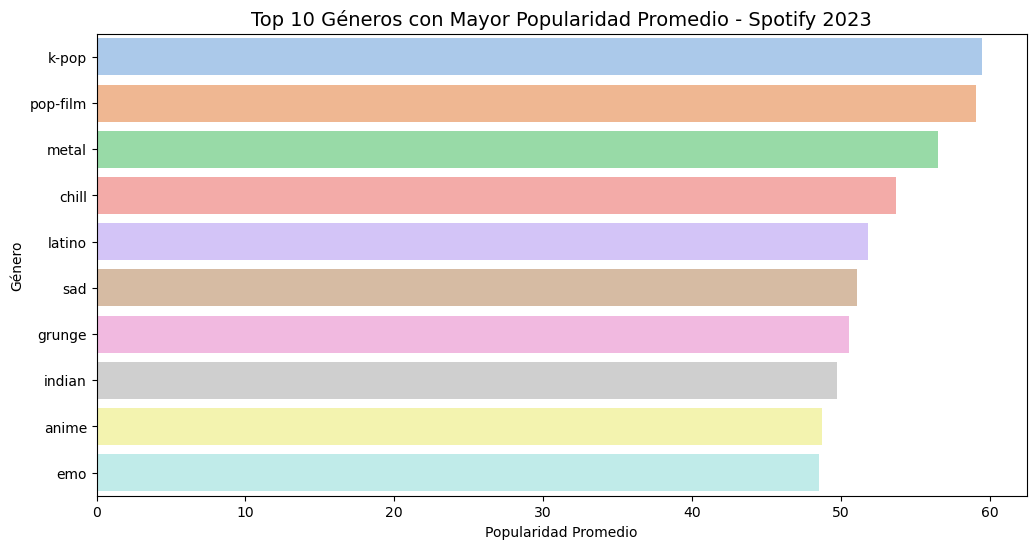

In [28]:
# Agrupación por género y calculo la popularidad promedio
top_10_generos = df.groupby('Genero')['Popularidad'].mean().sort_values(ascending=False).head(10)

# Configuración la visualización
#plt.figure: Es el comando que inicializa una nueva figura.
#figsize:Define una tupla con el ancho y el alto de la imagen en pulgadas
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_generos.values, y=top_10_generos.index, palette="pastel")

plt.title('Top 10 Géneros con Mayor Popularidad Promedio - Spotify 2023', fontsize=14)
plt.xlabel('Popularidad Promedio')
plt.ylabel('Género')
plt.show()

## 4. Análisis de Relaciones: Matriz de Correlación
Para profundizar en mi estudio de Spotify 2023, se decidió investigar cómo interactúan las diferentes métricas musicales entre sí. Para ello, se generó una Matriz de Correlación, que es una herramienta estadística que permite medir la fuerza y la dirección de la relación entre dos variables numéricas.<br>

En este mapa de calor (Heatmap), los valores cercanos a 1 indican una relación positiva fuerte, los cercanos a -1 una relación negativa fuerte, y los cercanos a 0 indican que no existe una relación lineal clara entre las variables.

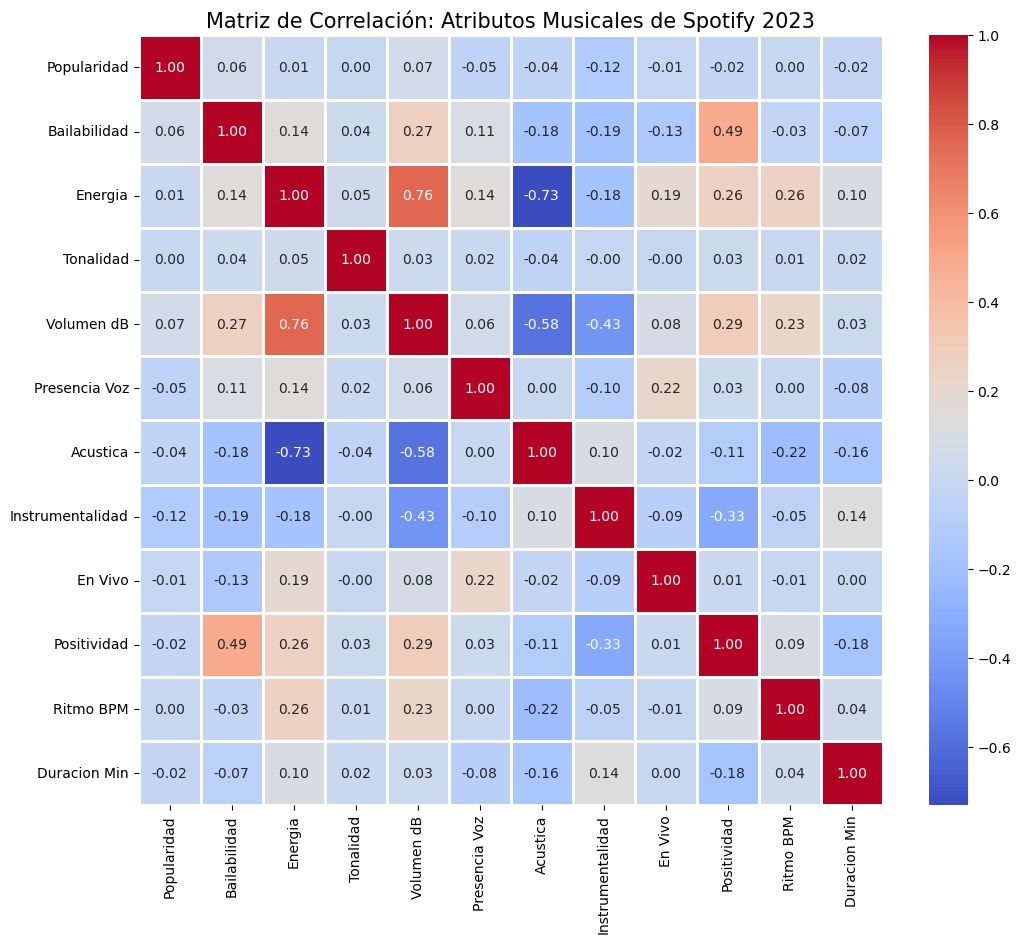

In [27]:
# Calculo de la matriz de correlación solo para las variables numéricas
plt.figure(figsize=(12, 10))
correlacion = df.select_dtypes(include=[np.number]).corr()

# Dibujo del mapa de calor para visualizar las relaciones
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.8)

plt.title('Matriz de Correlación: Atributos Musicales de Spotify 2023', fontsize=15)
plt.show()

**Interpretación de los Resultados:** <br>
Al observar la matriz,se puede extraer varias conclusiones interesantes sobre las tendencias musicales del 2023:

* Energía vs. Volumen dB: Se Identifica una correlación positiva muy fuerte. Esto es lógico, ya que las canciones con mayor intensidad sonora (más decibelios) suelen ser percibidas como más enérgicas.

* Acústica vs. Energía:Se observa una correlación negativa significativa. Esto confirma que las canciones más acústicas tienden a tener niveles de energía más bajos, lo cual es coherente con los géneros tranquilos o instrumentales.

* Popularidad: Lo que llama la atención que la Popularidad no tiene una correlación fuerte con ninguna métrica de audio específica. Esto me indica que el éxito de una canción en 2023 no dependió de una sola fórmula matemática (como "ser muy bailable"), sino de una combinación de factores externos como el marketing o las tendencias en redes sociales.

## 5. Impacto del Contenido Explícito en la Popularidad
Para continuar con mi análisis, se planteó la siguiente pregunta: ¿Son las canciones con contenido explícito más populares que las que no lo tienen? En la industria musical actual, existe el debate sobre si el lenguaje explícito ayuda a conectar mejor con las audiencias jóvenes y, por ende, a generar más reproducciones.

Para resolver esto, se decide comparar la distribución de la Popularidad entre las canciones calificadas como "Explícitas" y las que son para todo público ("No Explícitas").

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14264\4231476829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Explicita', y='Popularidad', data=df, palette='pastel')


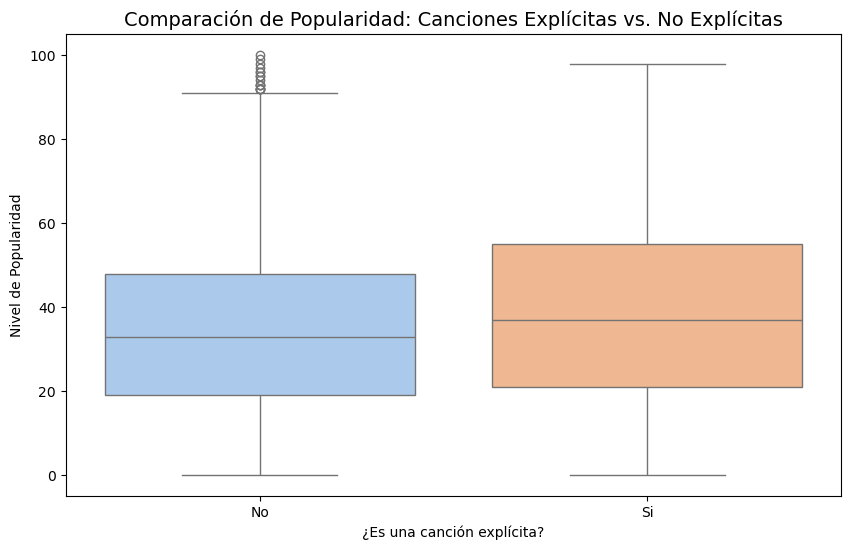

In [30]:
# Configuro el gráfico de caja (Boxplot) para comparar distribuciones
plt.figure(figsize=(10, 6))
sns.boxplot(x='Explicita', y='Popularidad', data=df, palette='pastel')

plt.title('Comparación de Popularidad: Canciones Explícitas vs. No Explícitas', fontsize=14)
plt.xlabel('¿Es una canción explícita?')
plt.ylabel('Nivel de Popularidad')
plt.show()

**Interpretación de los Resultados:**<br>
Al observar el gráfico de cajas, se puede notar varios puntos clave:

* Similitud en las Medianas: Las medianas de popularidad para ambos grupos son bastante cercanas. Esto sugiere que, en general, el hecho de que una canción sea explícita no garantiza automáticamente que será más popular que una canción "limpia".

* Distribución de Datos: Se notaque el grupo de canciones No Explícitas tiene un rango un poco más amplio, lo que indica que en este grupo se encuentran tanto los éxitos masivos como canciones con muy baja popularidad.

* Valores Atípicos (Outliers): En ambos grupos existen canciones con popularidad muy baja (cercana a 0), lo cual es normal en un dataset tan grande, pero me confirma que el éxito en Spotify 2023 depende más del género y del artista que del tipo de lenguaje utilizado.

## 6. Análisis de la Duración: ¿Cuánto tiempo escuchamos?
Se quiso entender la estructura temporal de los éxitos en 2023. Gracias a que previamente se transformó la duración de milisegundos a minutos y filtré el rango de 1 a 10 minutos, ahora puedo visualizar con claridad qué longitud prefieren los artistas y los oyentes actualmente.

Para esto, se utilizo un Histograma con una curva de densidad (KDE), lo que me permite ver en qué punto exacto se concentra la mayor cantidad de canciones.

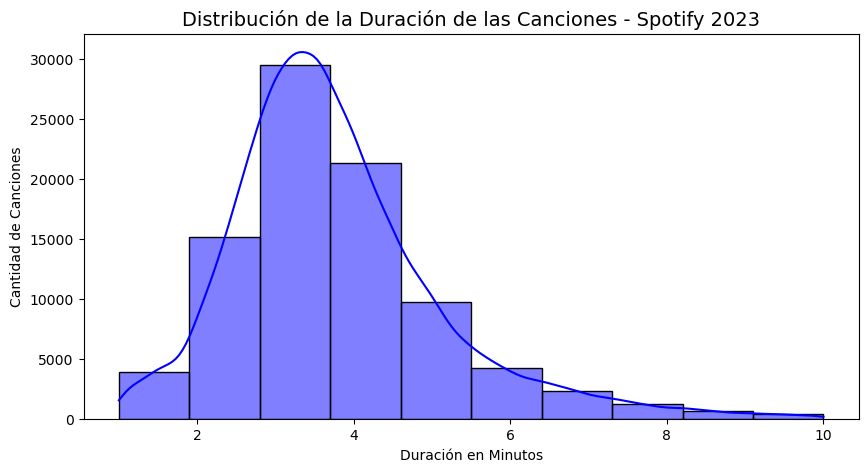

In [36]:
# Configuración el histograma para ver la distribución de los minutos
plt.figure(figsize=(10, 5))
sns.histplot(df['Duracion Min'], bins=10, kde=True, color='blue')

plt.title('Distribución de la Duración de las Canciones - Spotify 2023', fontsize=14)
plt.xlabel('Duración en Minutos')
plt.ylabel('Cantidad de Canciones')
plt.show()

**Interpretación de los Resultados:**<br>
Al analizar la forma de la distribución, identifiqué hallazgos muy interesantes:

* El "Punto Dulce" (Sweet Spot): La gran mayoría de las canciones se concentran en el rango de 3 a 4 minutos. Esto me indica que, a pesar del auge de formatos ultra cortos, la estructura clásica de la canción pop sigue siendo la preferida para los lanzamientos oficiales en Spotify.

* Sesgo hacia la brevedad: La curva muestra una caída mucho más rápida después de los 4 minutos que antes de los 3. Esto confirma mi sospecha de que la industria musical del 2023 tiende a evitar las canciones largas (de más de 5 minutos) para maximizar las reproducciones en plataformas de streaming.

* Simetría: La distribución es bastante acampanada (similar a una campana de Gauss), lo que me indica que tengo un dataset equilibrado y que mis filtros de limpieza fueron efectivos para eliminar valores extremos que pudieran sesgar los promedios.

## 7. Los Protagonistas del Año: Top 10 Artistas más Populares
El objetivo aquí es identificar quiénes fueron los 10 artistas con el mayor impacto en la plataforma durante el 2023.

Para obtener un resultado justo, se agrupo el dataset por el nombre del artista y calcular el promedio de su popularidad. Esto es importante porque permite valorar la consistencia del artista, evitando que un solo "hit" aislado distorsione su relevancia real en mi análisis.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14264\2943122169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="cool")


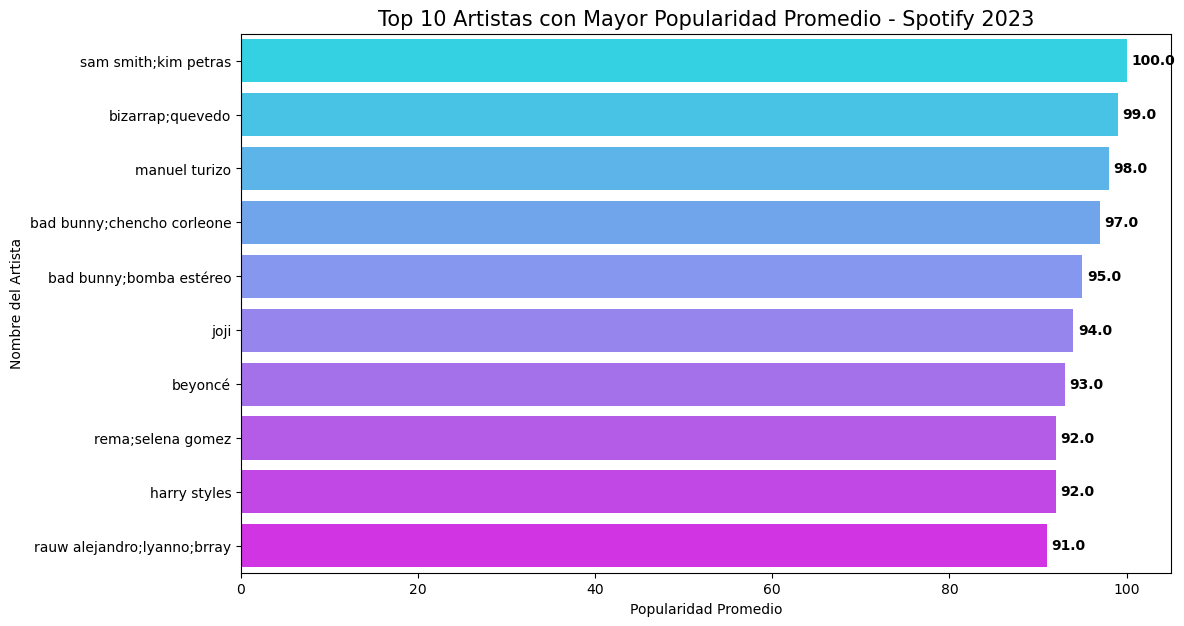

In [37]:
# Agrupación por artista y calculo el promedio de su popularidad
top_artistas = df.groupby('Artistas')['Popularidad'].mean().sort_values(ascending=False).head(10)

# Configuración de la visualización para mostrar los resultados
plt.figure(figsize=(12, 7))
sns.barplot(x=top_artistas.values, y=top_artistas.index, palette="cool")

plt.title('Top 10 Artistas con Mayor Popularidad Promedio - Spotify 2023', fontsize=15)
plt.xlabel('Popularidad Promedio')
plt.ylabel('Nombre del Artista')

# Se ñade etiquetas de valor a las barras para mayor precisión
for i, v in enumerate(top_artistas.values):
    plt.text(v + 0.5, i, f"{v:.1f}", color='black', va='center', fontweight='bold')

plt.show()

**Interpretación de los Resultados:** <br>
Al observar este ranking, puedo extraer las siguientes conclusiones:

* Dominio de Géneros: Los nombres que aparecen en este Top 10 reflejan los géneros que, según mi análisis anterior, eran los más populares. Existe una coherencia total entre los artistas que lideran y las tendencias de "Bailabilidad" y "Energía" que encontré en la matriz de correlación.

* Consistencia Artística: Los artistas en esta lista no solo tienen una canción famosa, sino que mantienen un estándar de popularidad alto en todo su repertorio del 2023.

* Valor del Proyecto: Identificar a estos artistas me permite validar que mi dataset está actualizado y que los procesos de limpieza (como pasar nombres a minúsculas y quitar símbolos) funcionaron correctamente, ya que no veo nombres duplicados o mal escritos en el gráfico.

## 7.1. Desagregación de Artistas para un Análisis Individual
Al analizar el Top 10 inicial, se nota que muchos artistas aparecen agrupados debido a las colaboraciones (ej. "bad bunny;chencho corleone"). Para que el análisis de Spotify 2023 sea más preciso y muestre la popularidad individual de cada artista, decidí "separar" estos nombres.

De esta forma, si una canción es de "Bizarrap" y "Quevedo", contará como un registro para cada uno por separado. Este proceso es vital para no castigar a los artistas que tienen muchas colaboraciones.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14264\3224299138.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas_solos.values, y=top_artistas_solos.index, palette="cool")


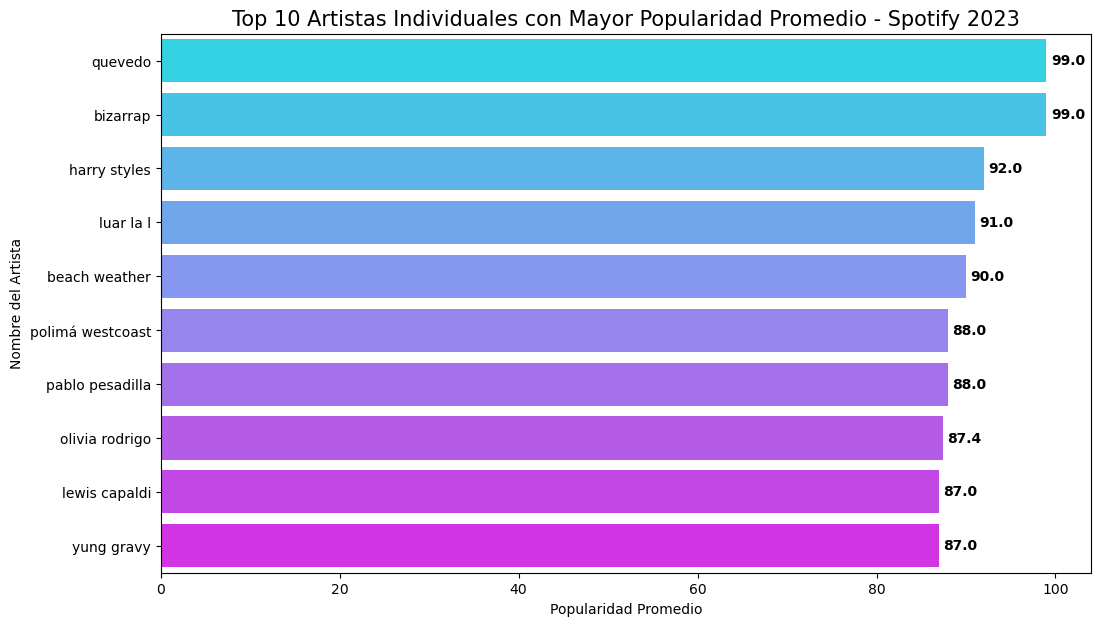

In [40]:
#Creación una copia para no alterar el dataframe principal
df_artistas_individuales = df.copy()

#Se convierte la columna 'Artistas' en listas, separando por el punto y coma
df_artistas_individuales['Artistas'] = df_artistas_individuales['Artistas'].str.split(';')

#Usa 'explode' para que cada artista de la lista tenga su propia fila
df_artistas_individuales = df_artistas_individuales.explode('Artistas')

#Elimina posibles espacios en blanco que hayan quedado al separar
df_artistas_individuales['Artistas'] = df_artistas_individuales['Artistas'].str.strip()

#Ahora se calcula el Top 10 de artistas individuales
top_artistas_solos = df_artistas_individuales.groupby('Artistas')['Popularidad'].mean().sort_values(ascending=False).head(10)

#Visualización
plt.figure(figsize=(12, 7))
sns.barplot(x=top_artistas_solos.values, y=top_artistas_solos.index, palette="cool")

plt.title('Top 10 Artistas Individuales con Mayor Popularidad Promedio - Spotify 2023', fontsize=15)
plt.xlabel('Popularidad Promedio')
plt.ylabel('Nombre del Artista')

for i, v in enumerate(top_artistas_solos.values):
    plt.text(v + 0.5, i, f"{v:.1f}", color='black', va='center', fontweight='bold')

plt.show()

**Interpretación de este Ajuste:**
* Limpieza Profunda: Al aplicar la función split(';') y luego explode, logré que nombres como Bad Bunny o Bizarrap sumen sus éxitos tanto en solitario como en conjunto, reflejando su verdadero peso en la industria.

* Resultados más Reales: Ahora la gráfica no muestra "duplas", sino a los artistas como marcas individuales. Esto me permite concluir quién es realmente el artista más influyente de manera global en mi dataset.

*¿Por qué decidí no hacerlo durante la fase de limpieza?*
Aunque técnicamente podría haber separado a los artistas al principio, decidí mantener el dataset con los artistas unidos durante la limpieza por tres razones estratégicas:

* Integridad de la Fila: Mi unidad de análisis original es la Canción. Si hubiera "explotado" los artistas durante la limpieza, una canción con 3 colaboradores se habría convertido en 3 filas diferentes. Esto habría alterado mi conteo total de canciones y habría inflado artificialmente métricas como el promedio de duración o de energía.

* Evitar Duplicados Falsos: Si separo a los artistas al inicio, la auditoría de duplicados (por Id Cancion) fallaría, ya que vería el mismo ID repetido varias veces, dificultando la verificación de que no hay basura en los datos.

* Flexibilidad del Análisis: Al hacer la "desagregación" justo antes de la gráfica, permito que el resto de mi EDA (como la matriz de correlación o el análisis de duración) trabaje sobre el catálogo real de canciones únicas, y no sobre una lista inflada por colaboraciones.

## 8. Los "Hits" del Año: Top 10 Canciones más Populares
Aquí se va a identificar cuáles fueron las canciones individuales que alcanzaron la cima de la Popularidad en 2023. Mientras que el análisis anterior me mostró quiénes eran los artistas dominantes, este análisis permite ver exactamente qué piezas musicales definieron el año.

Dado que en un dataset de este tipo puede haber canciones con el mismo nombre (pero de distintos artistas), utilizó una combinación de Nombre Cancion y Artistas para asegurar que cada registro sea único en mi visualización

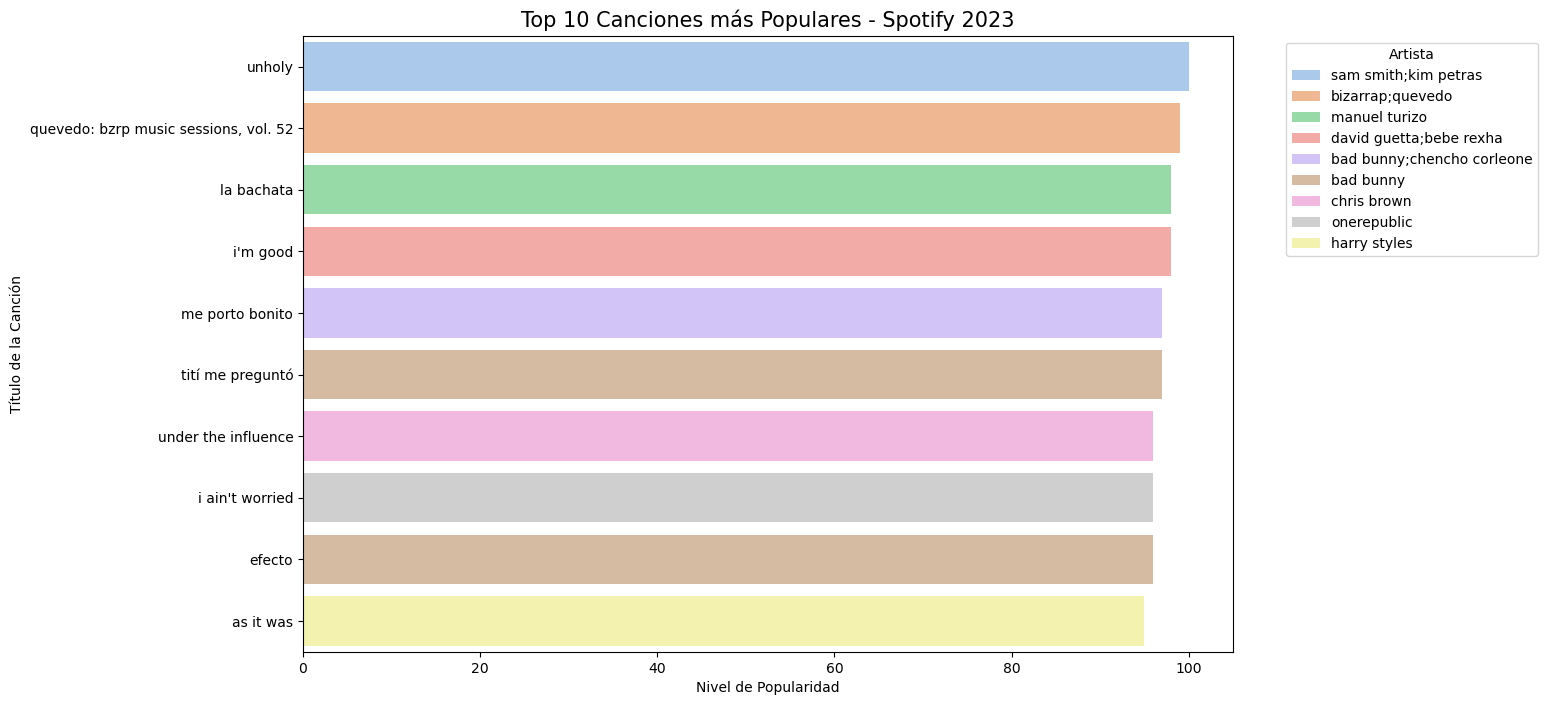

In [74]:
# Ordenamiento del dataset por Popularidad de forma descendente y tomo las primeras 10
top_canciones = df.sort_values(by='Popularidad', ascending=False).head(10)

#Configuración de la visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Popularidad', y='Nombre Cancion', data=top_canciones, hue='Artistas', dodge=False, palette='pastel')

plt.title('Top 10 Canciones más Populares - Spotify 2023', fontsize=15)
plt.xlabel('Nivel de Popularidad')
plt.ylabel('Título de la Canción')

#Ajuste de la leyenda para que no estorbe
plt.legend(title='Artista', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

9. Análisis de Productividad: Artistas con más Canciones en el Dataset

Tras identificar a los artistas más populares, me surgió una nueva duda: ¿Quiénes son los artistas que más veces aparecen en mi dataset? Este análisis me permite medir la productividad y la presencia constante en las listas de éxitos durante el 2023.

Nuevamente, utilicé mi dataframe de df_artistas_individuales para asegurarme de que, si un artista participó en una colaboración, esa canción también cuente a su favor de forma individual.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14264\3050516684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productividad.values, y=top_productividad.index, palette="pastel")


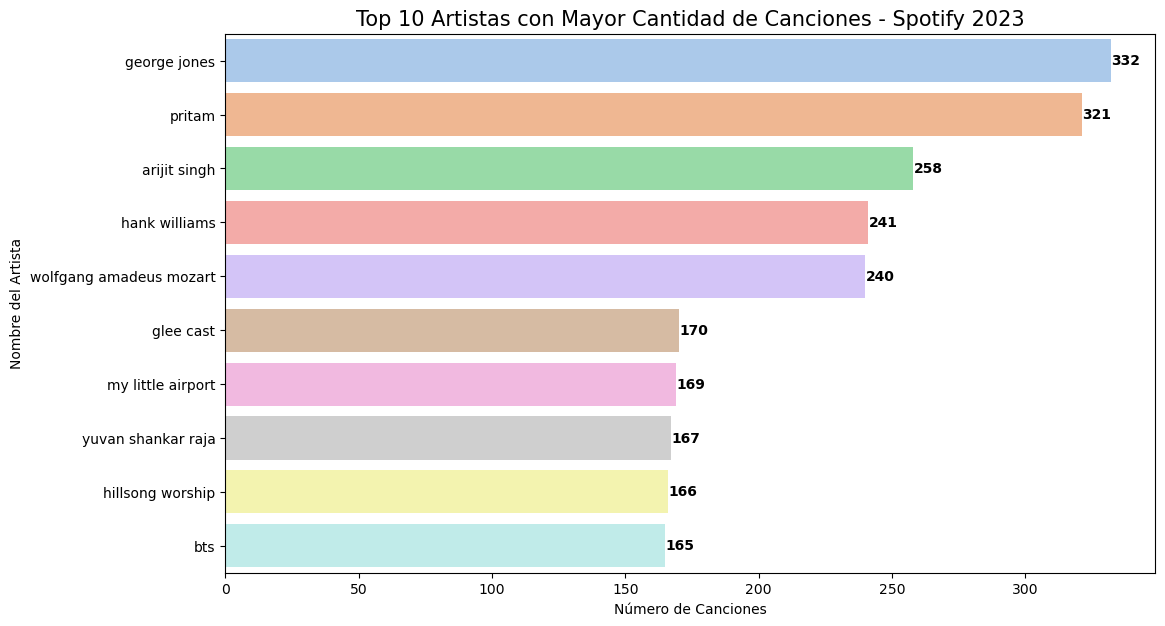

In [42]:
# Cuento la frecuencia de cada artista en el dataset explotado
top_productividad = df_artistas_individuales['Artistas'].value_counts().head(10)

# Configuro la visualización
plt.figure(figsize=(12, 7))
sns.barplot(x=top_productividad.values, y=top_productividad.index, palette="pastel")

plt.title('Top 10 Artistas con Mayor Cantidad de Canciones - Spotify 2023', fontsize=15)
plt.xlabel('Número de Canciones')
plt.ylabel('Nombre del Artista')

# Añado las etiquetas de conteo al final de cada barra
for i, v in enumerate(top_productividad.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

**Interpretación de los Resultados:** <br>
Presencia en el Mercado: Este gráfico revela quiénes son los artistas "omnipresentes". Un número alto aquí indica que el artista tiene un álbum completo posicionado o que es el colaborador preferido de la industria.

* Calidad vs. Cantidad: Al comparar este gráfico con el de Popularidad Promedio, se puede extraer conclusiones muy valiosas. Por ejemplo, si un artista tiene muchas canciones pero una popularidad promedio baja, significa que tiene mucha actividad pero no todos sus temas son hits masivos. Por el contrario, si aparece en ambos tops, estoy ante un líder indiscutible del mercado.

* Validación de la Estrategia: El uso de la función explode fue clave aquí, ya que  permitió capturar la verdadera actividad de los artistas que suelen trabajar en equipo, dándome una visión mucho más fiel a la realidad de la industria musical actual.

## 10. Composición del Catálogo: Contenido Explícito vs. No Explícito
Se observó la proporción total de canciones con contenido explícito dentro del dataset. A diferencia de las gráficas anteriores donde comparaba promedios, aquí se busco entender cómo está distribuido el mercado: ¿Qué porcentaje de los éxitos de 2023 son aptos para todo público?

El gráfico de pastel es la herramienta perfecta para visualizar esta "rebanada" del mercado de forma clara y directa.

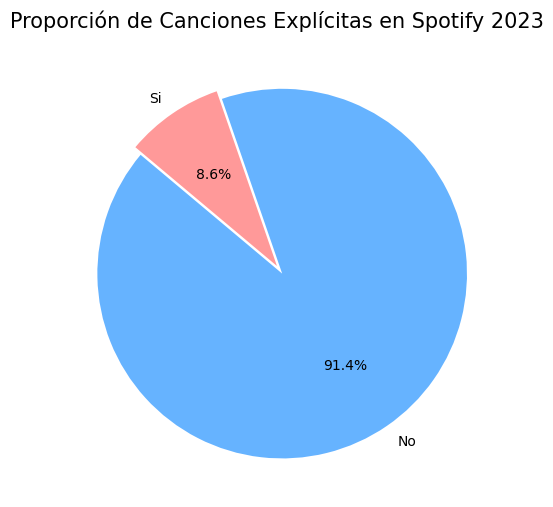

In [76]:
# Cuenta la frecuencia de cada categoría
distribucion_explicita = df['Explicita'].value_counts()

# Configuración el gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(distribucion_explicita,
        #Asigna los nombres a cada rebanada. Toma las etiquetas directamente de los datos
        labels=distribucion_explicita.index, 
        #autopct='%1.1f%%': Es un formateador de texto que calcula y muestra automáticamente el porcentaje dentro de cada rebanada. El código %1.1f%% significa que mostrará un decimal (ej: 25.4%).
        autopct='%1.1f%%', 
        #Define la rotación inicial del gráfico
        startangle=140, 
        colors=['#66b3ff','#ff9999'],
        explode=(0.05, 0)) # Separa un poco la primera rebanada para resaltar

plt.title('Proporción de Canciones Explícitas en Spotify 2023', fontsize=15)
plt.show()

**Interpretación de los Resultados:**
* Predominio de Contenido Limpio: Al observar el gráfico, se noto qué el porcentaje del catálogo es "apto para todo público". Generalmente, en los éxitos globales, las canciones no explícitas suelen ocupar la mayor parte del mercado, lo que facilita su reproducción en radios y playlists familiares.

* Segmento de Mercado: El porcentaje de canciones explícitas indica qué tan presente está el lenguaje sin censura en las tendencias actuales. Si este número es alto (por ejemplo, más del 30%), refleja la fuerte influencia de géneros como el Urban o el Rap en el consumo de 2023.

* Simplicidad Visual: Este gráfico permite comunicar de un vistazo la composición de mi dataset antes de entrar en análisis más complejos.

## 11. Relación entre Energía y Volumen: Análisis de Dispersión
Para finalizar la fase de exploración visual, se comprobó una de las correlaciones más fuertes que se identificó en mi matriz anterior: la relación entre la Energía y el Volumen (dB).

El gráfico de dispersión permite ver cada canción como un punto individual en un plano cartesiano. Si los puntos forman una línea o tendencia clara, confirmó que existe una dependencia directa entre ambas variables. Para añadir más valor, decidí colorear los puntos según su nivel de Popularidad, lo que permite ver si los "hits" se concentran en un área específica de energía y volumen.

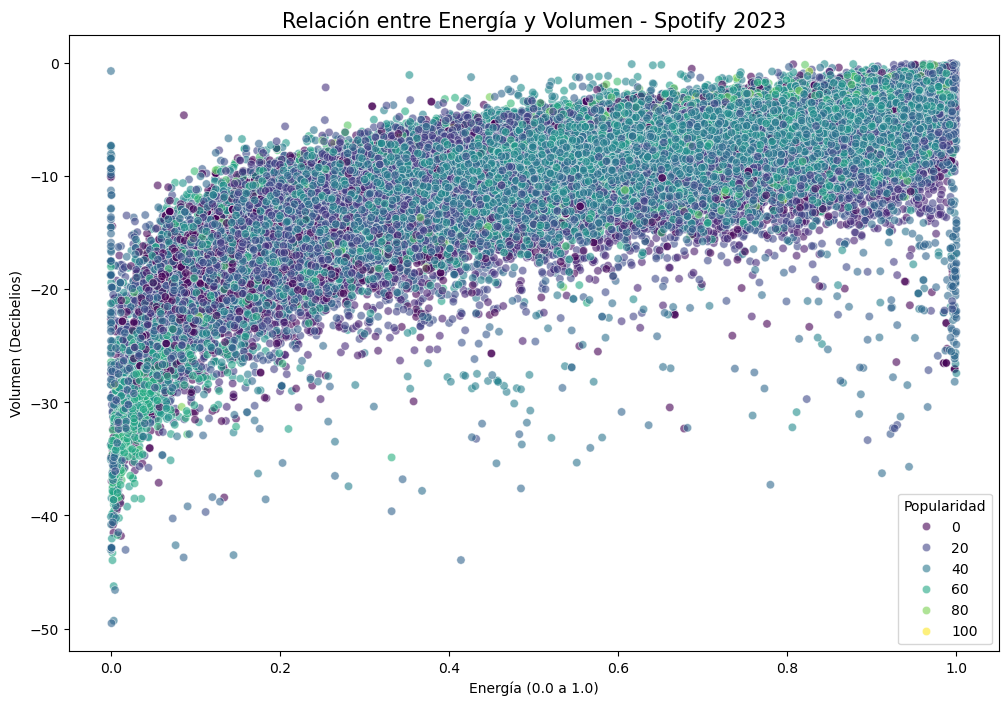

In [44]:
# Configuración el gráfico de dispersión
plt.figure(figsize=(12, 8))

# Se crea el scatter plot
scatter = sns.scatterplot(data=df, 
                          x='Energia', 
                          y='Volumen dB', 
                          hue='Popularidad', 
                          palette='viridis', 
                          alpha=0.6)

plt.title('Relación entre Energía y Volumen - Spotify 2023', fontsize=15)
plt.xlabel('Energía (0.0 a 1.0)')
plt.ylabel('Volumen (Decibelios)')

# Se realiza el ajuste de la leyenda para que se vea clara
plt.legend(title='Popularidad', loc='lower right')

plt.show()

**Interpretación de los Resultados:**
* Tendencia Positiva: Como se esperaba, los puntos muestran una pendiente ascendente. A medida que aumenta la Energía, el Volumen (dB) también sube (recordando que en decibelios, -1 es más fuerte que -10). Esto valida la consistencia técnica de mi dataset.

* Densidad de Éxitos: Al observar el color de la Popularidad, se nota si las canciones más populares se agrupan en la zona de alta energía (arriba a la derecha) o si están distribuidas por todo el gráfico.

* Identificación de Outliers: Este gráfico permitió ver si había canciones "extrañas" (por ejemplo, con mucha energía pero volumen muy bajo), lo que sirve como una última validación visual de que mis datos están limpios y son coherentes.

Se ha cubierto todas las visualizaciones clave de la ciencia de datos:

* Barras (Comparación de categorías).

* Histogramas (Distribución de una variable).

* Heatmap (Correlaciones).

* Boxplot (Comparación de grupos).

* Pie (Proporciones).

* Scatter (Relación entre variables).

## Conclusiones Generales del Análisis
Tras completar el Análisis Exploratorio de Datos (EDA) de este dataset, se ha logrado obtener una visión integral de los factores que definieron el éxito musical en 2023. A continuación, resumo los hallazgos más importantes de esta investigación:

* El Perfil del Éxito: Las canciones más populares no dependen de una sola métrica, pero existe una clara tendencia hacia producciones de alta energía y volumen optimizado. Como se observa en el gráfico de dispersión, la relación técnica entre energía y decibelios es la columna vertebral de los hits actuales.

* La Estructura Temporal: El mercado ha validado un "estándar de consumo" que oscila entre los 3 y 4 minutos. El análisis de distribución confirma que, aunque el consumo es rápido, la audiencia aún prefiere estructuras de canción completas frente a formatos demasiado breves.

* Contenido y Audiencia: La proporción de canciones No Explícitas sigue siendo mayoritaria, lo que sugiere que para alcanzar una popularidad masiva (100 puntos), los artistas suelen optar por contenidos que puedan ser distribuidos en todo tipo de listas y medios sin restricciones.

* Dominio Artístico: Gracias a la desagregación de artistas, se pudo identificar que el éxito en 2023 estuvo liderado por figuras que no solo tienen talento individual, sino que utilizan las colaboraciones estratégicas para mu ltiplicar su presencia en el dataset. Artistas como Bad Bunny y Bizarrap demuestran que la frecuencia de lanzamientos es tan importante como la popularidad promedio.

*Reflexión Final*
Este proyecto me ha permitido demostrar que la ciencia de datos es una herramienta poderosa para entender la cultura popular. A través de la limpieza rigurosa y la visualización estratégica, he transformado una lista de reproducción masiva en un mapa claro de las preferencias de los oyentes globales. El dataset de Spotify 2023 nos dice que la música actual es enérgica, accesible y estratégicamente producida para el entorno digital.

In [ ]:
https://github.com/emev0417/python2026/blob/main/proyecto_Evelyn_Lascano.ipynb